In [2]:
# Load Dataset

import pandas as pd

df = pd.read_csv(
    "../data/NAB/realAWSCloudwatch/ec2_cpu_utilization_5f5533.csv"
)

print(df.shape)

df.head()

(4032, 2)


,timestamp,value
0,2014-02-14 14:27:00,51.846
1,2014-02-14 14:32:00,44.508
2,2014-02-14 14:37:00,41.244
3,2014-02-14 14:42:00,48.568
4,2014-02-14 14:47:00,46.714


In [ ]:
# Convert Timestamp
df["timestamp"] = pd.to_datetime(
    df["timestamp"]
)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4032 entries, 0 to 4031
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  4032 non-null   datetime64[us]
 1   value      4032 non-null   float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 63.1 KB


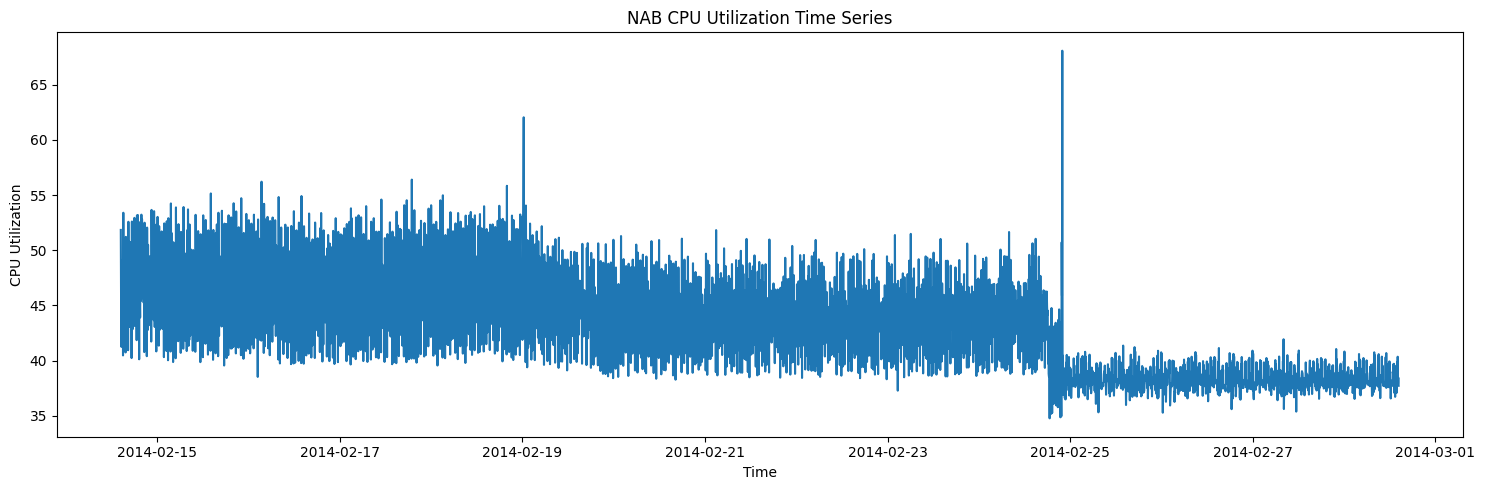

In [4]:
# Plot Time Series

import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(
    df["timestamp"],
    df["value"]
)

plt.title(
    "NAB CPU Utilization Time Series"
)

plt.xlabel("Time")
plt.ylabel("CPU Utilization")

plt.tight_layout()

plt.savefig(
    "../reports/figures/nab_timeseries.png",
    dpi=300
)

plt.show()

In [5]:
# Isolation Forest

from sklearn.ensemble import IsolationForest

X = df[["value"]]

iso_model = IsolationForest(
    contamination=0.02,
    random_state=42
)

df["anomaly_iso"] = iso_model.fit_predict(X)

df["anomaly_iso"] = df["anomaly_iso"].map({
    1:0,
    -1:1
})

df["anomaly_iso"].value_counts()

anomaly_iso
0    3952
1      80
Name: count, dtype: int64

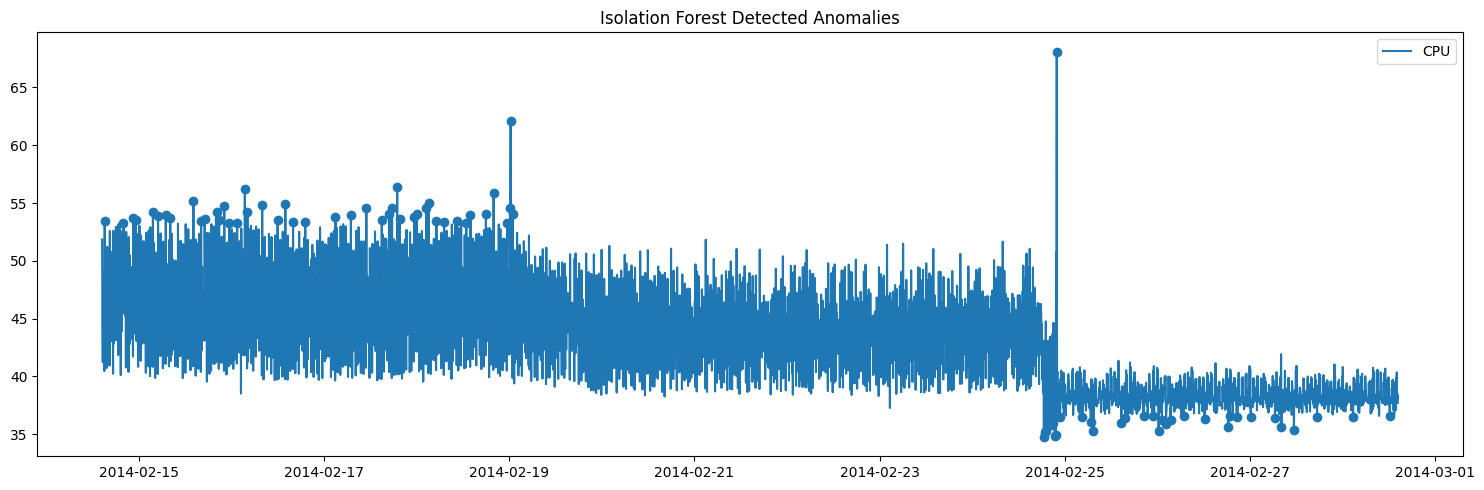

In [6]:
# Visualize Anomalies

plt.figure(figsize=(15,5))

plt.plot(
    df["timestamp"],
    df["value"],
    label="CPU"
)

anomalies = df[
    df["anomaly_iso"] == 1
]

plt.scatter(
    anomalies["timestamp"],
    anomalies["value"]
)

plt.title(
    "Isolation Forest Detected Anomalies"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "../reports/figures/nab_isolation_forest.png",
    dpi=300
)

plt.show()

In [7]:
# LOF

from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(
    contamination=0.02,
    n_neighbors=20
)

pred = lof.fit_predict(
    X
)

df["anomaly_lof"] = pd.Series(pred).map({
    1:0,
    -1:1
})

df["anomaly_lof"].value_counts()

anomaly_lof
0    3952
1      80
Name: count, dtype: int64

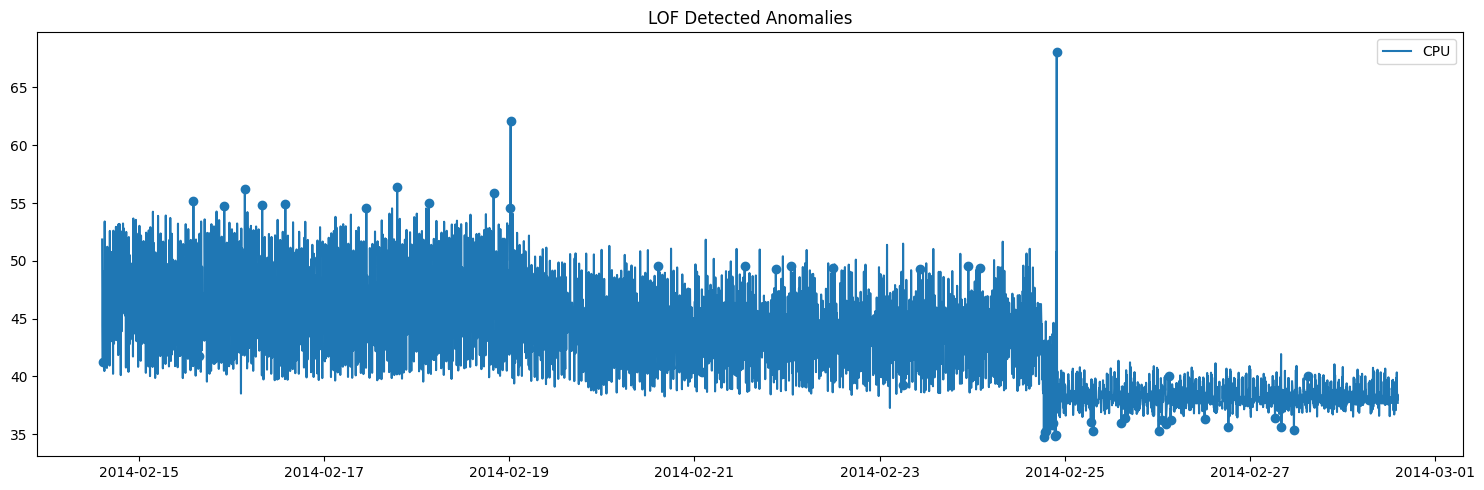

In [8]:
# Visualize LOF

plt.figure(figsize=(15,5))

plt.plot(
    df["timestamp"],
    df["value"],
    label="CPU"
)

anomalies = df[
    df["anomaly_lof"] == 1
]

plt.scatter(
    anomalies["timestamp"],
    anomalies["value"]
)

plt.title(
    "LOF Detected Anomalies"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "../reports/figures/nab_lof.png",
    dpi=300
)

plt.show()

In [9]:
# NAB Summary Table

nab_results = pd.DataFrame({

    "Model":[
        "Isolation Forest",
        "LOF"
    ],

    "Detected_Anomalies":[
        df["anomaly_iso"].sum(),
        df["anomaly_lof"].sum()
    ]
})

nab_results

,Model,Detected_Anomalies
0,Isolation Forest,80
1,LOF,80


In [ ]:
# Save Results

nab_results.to_csv(
    "../reports/results/nab_results.csv",
    index=False
)